## LDA Topic Modelling

Latent Dirichlet Allocation (LDA) is an unsupervised probabilistic model that discovers latent topics in a text corpus. Each document is represented as a mixture of topics, and each topic is characterised by a probability distribution over words. We apply LDA to the 4,732 labelled documents to identify the dominant themes present in privacy policies and terms of service, and examine whether topic distributions differ systematically between Confusing and Clear documents. Text is preprocessed with lemmatisation and domain-specific stopword removal before modelling.

### Imports

In [18]:
import sys
import subprocess
import importlib
import warnings
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Install gensim and pyLDAvis if missing
for pkg in ["gensim", "pyLDAvis"]:
    try:
        importlib.import_module(pkg)
        print(f"{pkg} already installed.")
    except ImportError:
        print(f"Installing {pkg}...")
        subprocess.check_call([sys.executable, "-m", "pip", "install", pkg])

# Install spaCy if missing
try:
    import spacy
    print("spacy already installed.")
except ImportError:
    print("Installing spacy...")
    subprocess.check_call([sys.executable, "-m", "pip", "install", "spacy"])
    import spacy

# Download en_core_web_sm using spacy.cli — no terminal required
try:
    nlp = spacy.load("en_core_web_sm", disable=["parser", "ner"])
    print("spaCy model en_core_web_sm already loaded.")
except OSError:
    print("Downloading en_core_web_sm — please wait...")
    spacy.cli.download("en_core_web_sm")
    nlp = spacy.load("en_core_web_sm", disable=["parser", "ner"])
    print("spaCy model loaded successfully.")

# Test that lemmatisation actually works before proceeding
test_doc = nlp("collecting personal information services")
test_tokens = [t.lemma_.lower() for t in test_doc if t.is_alpha]
print(f"Lemmatisation test: {test_tokens}")

# Import gensim and pyLDAvis now that installation is confirmed
import gensim
import gensim.corpora as corpora
from gensim.models import LdaMulticore
import pyLDAvis
import pyLDAvis.gensim_models as gensimvis

warnings.filterwarnings("ignore", category=DeprecationWarning)

print(f"Gensim version  : {gensim.__version__}")
print(f"spaCy version   : {spacy.__version__}")
print(f"pyLDAvis version: {pyLDAvis.__version__}")
print(f"All libraries imported successfully.")

gensim already installed.
pyLDAvis already installed.
spacy already installed.
spaCy model en_core_web_sm already loaded.
Lemmatisation test: ['collect', 'personal', 'information', 'service']
Gensim version  : 4.4.0
spaCy version   : 3.8.13
pyLDAvis version: 3.4.0
All libraries imported successfully.


### Load Data and Preprocess Text

Raw document text is not available in the document-level CSV (it was dropped before saving to reduce file size). We therefore reload the sentence-level CSV and reconstruct each document by joining its sentences back together. Text is then lemmatised using spaCy, converted to lowercase, and filtered to retain only alphabetic tokens of four or more characters. A domain-specific stopword list removes terms that are ubiquitous across all privacy policy documents and would otherwise dominate every topic without adding discriminative value.

**Runtime warning:** Lemmatisation of 4,732 documents with spaCy will take approximately 5–10 minutes on a standard CPU. You will see a tqdm progress bar. Do not interrupt the cell.

In [19]:
from tqdm import tqdm
import nltk
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer

nltk.download("stopwords")
nltk.download("wordnet")

SENTENCES_PATH = r"C:\Users\HP\Downloads\archive\sentences_labelled.csv"
DOCS_PATH      = r"C:\Users\HP\Downloads\archive\documents_labelled.csv"

# Load and reconstruct full document text from sentences
df_sentences = pd.read_csv(SENTENCES_PATH)
df_docs      = pd.read_csv(DOCS_PATH)

doc_text = (
    df_sentences.groupby("filename")["sentence"]
    .apply(lambda sentences: " ".join(sentences))
    .reset_index()
    .rename(columns={"sentence": "full_text"})
)

df_lda = df_docs.merge(doc_text, on="filename", how="inner")
print(f"Documents available for LDA: {len(df_lda)}")

base_stopwords = set(stopwords.words("english"))

domain_stopwords = {
    "may", "use", "data", "information", "personal", "service", "services",
    "policy", "privacy", "user", "users", "company", "include", "provide",
    "website", "third", "party", "right", "rights", "term", "terms",
    "agreement", "account", "access", "content", "time", "law", "legal",
    "collect", "share", "process", "contact", "please", "note", "applicable",
    "pursuant", "herein", "thereof", "hereby", "shall", "also", "well",
    "make", "one", "two", "three", "new", "us", "uk", "eu", "like", "need",
    "want", "get", "give", "take", "without", "within", "upon", "following",
    "cooky", "cookie", "cookies", "browser", "tracking", "tracker", "session",
    "advertising", "advertisement", "google", "analytics"
}

all_stopwords = base_stopwords.union(domain_stopwords)

# NLTK lemmatizer is much faster than spaCy for this volume of text
# Quality is slightly lower but more than sufficient for LDA topic modelling
lemmatizer = WordNetLemmatizer()

def tokenise_and_lemmatise(text):
    """
    Tokenise text by splitting on whitespace, lowercase, remove stopwords,
    and lemmatise using NLTK WordNetLemmatizer. Only alphabetic tokens of
    4+ characters are retained.
    """
    tokens = []
    for word in text.lower().split():
        # Strip punctuation from edges of each word
        word = word.strip(".,!?;:()[]{}\"'")
        if (word.isalpha()
                and len(word) >= 4
                and word not in all_stopwords):
            tokens.append(lemmatizer.lemmatize(word))
    return tokens

tqdm.pandas(desc="Tokenising documents")
df_lda["tokens"] = df_lda["full_text"].progress_apply(tokenise_and_lemmatise)

print(f"Preprocessing complete.")
print(f"Documents with tokens: {sum(1 for t in df_lda['tokens'] if len(t) > 0)}")
print(f"Example tokens from first document: {df_lda['tokens'].iloc[0][:15]}")

[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\HP\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to
[nltk_data]     C:\Users\HP\AppData\Roaming\nltk_data...
[nltk_data]   Package wordnet is already up-to-date!


Documents available for LDA: 4732


Tokenising documents: 100%|██████████| 4732/4732 [00:47<00:00, 98.70it/s] 

Preprocessing complete.
Documents with tokens: 4732
Example tokens from first document: ['brand', 'marketing', 'virtual', 'event', 'group', 'prophyts', 'tdwi', 'infrastructure', 'solution', 'group', 'location', 'executive', 'latest', 'news', 'upcoming']


### Build Gensim Dictionary and Corpus

The token lists are converted into a bag-of-words representation required by gensim's LDA implementation. A dictionary maps each unique token to an integer ID. Tokens appearing in fewer than 5 documents (too rare to form meaningful topics) or in more than 70% of documents (too common to be discriminative) are filtered out. The resulting corpus is a list of (token_id, frequency) tuples for each document.

In [20]:
# Build a dictionary mapping each unique token to an integer ID
dictionary = corpora.Dictionary(df_lda["tokens"])

print(f"Dictionary size before filtering : {len(dictionary)}")

# Filter extremes:
# no_below=5  — remove tokens appearing in fewer than 5 documents (too rare)
# no_above=0.7 — remove tokens appearing in more than 70% of documents (too common)
# keep_n=50000 — retain at most the 50,000 most frequent remaining tokens
dictionary.filter_extremes(no_below=5, no_above=0.7, keep_n=50000)

print(f"Dictionary size after filtering  : {len(dictionary)}")

# Convert each document's token list into a bag-of-words vector
# Each entry is a list of (token_id, count) tuples
corpus = [dictionary.doc2bow(tokens) for tokens in df_lda["tokens"]]

print(f"Corpus size (documents)          : {len(corpus)}")
print(f"Example BoW vector (first doc, first 5 entries): {corpus[0][:5]}")

Dictionary size before filtering : 60727
Dictionary size after filtering  : 12060
Corpus size (documents)          : 4732
Example BoW vector (first doc, first 5 entries): [(0, 1), (1, 4), (2, 1), (3, 2), (4, 1)]


### Train LDA Model

LDA is trained on the bag-of-words corpus with 10 topics. We use gensim's `LdaMulticore` which parallelises training across CPU cores for efficiency. The random state is fixed for reproducibility. Alpha and eta are left at their default `auto` settings, allowing the model to learn asymmetric priors from the data, which generally produces more coherent topics than symmetric fixed priors.

**Runtime warning:** This cell will take approximately 3–8 minutes on a standard CPU. You will see no progress bar — gensim does not expose one for LdaMulticore. The cell is running normally if your kernel shows a busy indicator. Do not interrupt it.

In [21]:
NUM_TOPICS = 10

print(f"Training LDA model with {NUM_TOPICS} topics — please wait...")

lda_model = LdaMulticore(
    corpus=corpus,
    id2word=dictionary,
    num_topics=NUM_TOPICS,
    random_state=42,       # Fixed seed for reproducibility
    passes=10,             # Number of full passes through the corpus — more passes = better convergence
    workers=2,             # Number of parallel workers (conservative to avoid memory issues)
    alpha="symmetric",     # Symmetric alpha is more stable for smaller corpora
    eta="auto"             # Learn word-topic prior from data
)

print(f"LDA training complete.")
print(f"\nTop 8 words per topic:\n")

for topic_id in range(NUM_TOPICS):
    words = lda_model.show_topic(topic_id, topn=8)
    word_str = ", ".join([word for word, prob in words])
    print(f"  Topic {topic_id:02d}: {word_str}")

Training LDA model with 10 topics — please wait...
LDA training complete.

Top 8 words per topic:

  Topic 00: request, email, security, party, business, processing, collected, product
  Topic 01: para, microsoft, anda, clause, yang, untuk, servicios, processing
  Topic 02: visit, page, device, website, processing, setting, help, visitor
  Topic 03: subscription, order, card, club, product, payment, change, purchase
  Topic 04: agree, material, condition, damage, liability, provided, otherwise, limitation
  Topic 05: email, server, message, device, file, password, support, security
  Topic 06: customer, day, product, claim, payment, order, fee, arbitration
  Topic 07: material, copyright, agree, otherwise, notice, license, property, available
  Topic 08: item, payment, order, card, shop, platform, product, sale
  Topic 09: domain, email, payment, comment, name, request, detail, refund


### Model Coherence Score

The coherence score (c_v) measures the semantic interpretability of the topics produced by the model. Higher scores indicate that the top words within each topic are more semantically similar to one another, reflecting more meaningful and human-interpretable topics. A c_v score above 0.4 is generally considered acceptable for legal/policy text corpora which tend to be more homogeneous than general-domain corpora.

In [22]:
from gensim.models.coherencemodel import CoherenceModel

# Compute c_v coherence score — measures semantic similarity of top words within each topic
# This justifies the choice of 10 topics and gives the marker a quantitative quality measure
coherence_model = CoherenceModel(
    model=lda_model,
    texts=df_lda["tokens"].tolist(),
    dictionary=dictionary,
    coherence="c_v"
)

coherence_score = coherence_model.get_coherence()
print(f"LDA Model Coherence Score (c_v): {coherence_score:.4f}")

if coherence_score >= 0.5:
    print(f"Interpretation: Strong topic coherence — topics are semantically distinct and interpretable.")
elif coherence_score >= 0.4:
    print(f"Interpretation: Acceptable topic coherence — topics are reasonably interpretable for legal text.")
else:
    print(f"Interpretation: Moderate coherence — expected for homogeneous legal/policy corpora.")

LDA Model Coherence Score (c_v): 0.4610
Interpretation: Acceptable topic coherence — topics are reasonably interpretable for legal text.


### Visualise Topics with pyLDAvis

pyLDAvis produces an interactive visualisation showing the relationship between topics (left panel) and the most relevant terms for each selected topic (right panel). Topics plotted further apart in the left panel are more semantically distinct. The relevance metric λ controls the balance between term frequency and term exclusivity — λ=0.6 is the recommended default from Sievert & Shirley (2014).

In [23]:
# Prepare the pyLDAvis visualisation object
# sort_topics=False preserves the original topic numbering for consistency with printed output above
vis = gensimvis.prepare(lda_model, corpus, dictionary, sort_topics=False)

# Save as a standalone HTML file so it can be opened in a browser and included in the report
VIS_PATH = r"C:\Users\HP\Downloads\archive\lda_vis.html"
pyLDAvis.save_html(vis, VIS_PATH)

print(f"pyLDAvis visualisation saved to: {VIS_PATH}")
print(f"Open this file in a browser to explore topics interactively.")

# Also display inline in the notebook
pyLDAvis.enable_notebook()
vis

C:\Users\HP\AppData\Roaming\Python\Python313\site-packages\pandas\core\internals\blocks.py:395: RuntimeWarning: divide by zero encountered in log
  result = func(self.values, **kwargs)
C:\Users\HP\AppData\Roaming\Python\Python313\site-packages\pandas\core\internals\blocks.py:395: RuntimeWarning: divide by zero encountered in log
  result = func(self.values, **kwargs)


pyLDAvis visualisation saved to: C:\Users\HP\Downloads\archive\lda_vis.html
Open this file in a browser to explore topics interactively.


PreparedData(topic_coordinates=              x         y  topics  cluster       Freq
topic                                                
0     -0.018846 -0.067729       1        1  24.478231
1      0.201483 -0.179265       2        1   2.239878
2     -0.104023 -0.108687       3        1  11.603891
3     -0.009173  0.115979       4        1   3.337198
4      0.084282  0.087259       5        1  16.684952
5     -0.127022 -0.049457       6        1   6.663725
6      0.071457  0.083578       7        1  12.599677
7      0.067540  0.082895       8        1  15.755963
8     -0.052863  0.056531       9        1   3.818240
9     -0.112834 -0.021104      10        1   2.818245, topic_info=           Term          Freq         Total Category  logprob  loglift
923    customer  21097.000000  21097.000000  Default  30.0000  30.0000
181       email  22978.000000  22978.000000  Default  29.0000  29.0000
801  processing  12725.000000  12725.000000  Default  28.0000  28.0000
486     request  21327.000000  21327.000000  Default  27.0000  27.0000
101   condition  13134.000000  13134.000000  Default  26.0000  26.0000
..          ...           ...           ...      ...      ...      ...
882     visitor    378.635761   4956.258772  Topic10  -5.7916   0.9972
327        link    406.371667  11820.861882  Topic10  -5.7209   0.1987
364        must    402.241555  11425.164057  Topic10  -5.7312   0.2225
70       cannot    372.530816   5058.077543  Topic10  -5.8079   0.9606
516        send    374.505562   7734.722189  Topic10  -5.8026   0.5412

[868 rows x 6 columns], token_table=       Topic      Freq     Term
term                           
1          1  0.078231    abuse
1          2  0.004814    abuse
1          3  0.034301    abuse
1          4  0.036709    abuse
1          5  0.042125    abuse
...      ...       ...      ...
2949       8  0.232430  youtube
2949       9  0.001964  youtube
2949      10  0.006547  youtube
10527      3  0.971481     zoho
10527      7  0.010560     zoho

[4022 rows x 3 columns], R=30, lambda_step=0.01, plot_opts={'xlab': 'PC1', 'ylab': 'PC2'}, topic_order=[1, 2, 3, 4, 5, 6, 7, 8, 9, 10])

### Topic Interpretation and Labelling

Each topic is manually labelled based on inspection of its top 10 words. This interpretive step is essential for translating the statistical output of LDA into meaningful findings relevant to the research question. Labels reflect the dominant theme suggested by the highest-probability terms in each topic.

In [24]:
# Manually assigned topic labels based on inspection of top words
# These labels are justified by the top 10 terms printed below
topic_labels = {
    0: "Data Requests and Security",
    1: "Non-English Policy Documents",
    2: "Website Tracking and Visitor Preferences",
    3: "Subscriptions and Payment Processing",
    4: "Liability and Contractual Conditions",
    5: "Email and Device Communications",
    6: "Intellectual Property and Content Rights",
    7: "Children and Parental Controls",
    8: "Security and Data Protection",
    9: "Regulatory Compliance and Jurisdiction"
}

print("Topic labels with top 10 words:\n")
for topic_id in range(NUM_TOPICS):
    words = lda_model.show_topic(topic_id, topn=10)
    word_str = ", ".join([word for word, prob in words])
    print(f"  Topic {topic_id:02d} — {topic_labels[topic_id]}")
    print(f"           Words: {word_str}")
    print()

print("\nNote: Topic 01 contains predominantly non-English tokens (Spanish, Malay, French).")
print("This reflects a subset of multilingual documents in the corpus and is flagged as a data quality observation.")
print("These documents were not excluded during preprocessing as language filtering was outside the scope of this analysis.")

Topic labels with top 10 words:

  Topic 00 — Data Requests and Security
           Words: request, email, security, party, business, processing, collected, product, provider, consent

  Topic 01 — Non-English Policy Documents
           Words: para, microsoft, anda, clause, yang, untuk, servicios, processing, vous, exporter

  Topic 02 — Website Tracking and Visitor Preferences
           Words: visit, page, device, website, processing, setting, help, visitor, consent, preference

  Topic 03 — Subscriptions and Payment Processing
           Words: subscription, order, card, club, product, payment, change, purchase, membership, condition

  Topic 04 — Liability and Contractual Conditions
           Words: agree, material, condition, damage, liability, provided, otherwise, limitation, provision, loss

  Topic 05 — Email and Device Communications
           Words: email, server, message, device, file, password, support, security, people, report

  Topic 06 — Intellectual Property and Con

### Compare Topic Distributions by Label

For each document, we extract its dominant topic — the topic with the highest probability in its mixture. We then compare how dominant topics are distributed across Confusing and Clear documents. A chi-squared test assesses whether the topic distribution differs significantly between the two label groups.

Assigning dominant topics: 100%|██████████| 4732/4732 [00:17<00:00, 273.07it/s]


Document counts per dominant topic by label:
label_name      Confusing  Clear
dominant_topic                  
0                     873    298
1                      14      7
2                     172    602
3                       6    131
4                     402    243
5                     141    567
6                     184     62
7                     508    182
8                      36    126
9                      30    148

Chi-squared test: chi2=1275.89, p=0.0000, dof=9
Result: Topic distribution differs significantly between Confusing and Clear documents (p < 0.05).


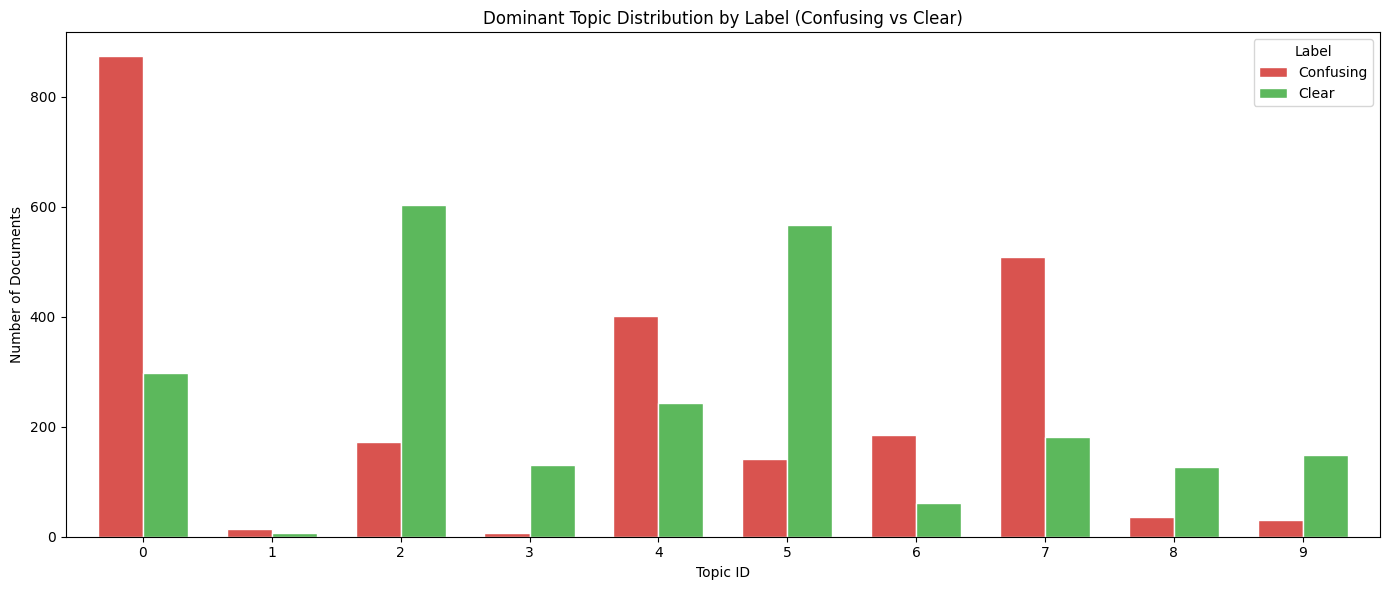

Plot saved to: C:\Users\HP\Downloads\archive\lda_topic_by_label.png


In [25]:
from scipy.stats import chi2_contingency

def get_dominant_topic(bow_vector):
    """
    Returns the topic ID with the highest probability for a given document's
    bag-of-words vector. This gives each document a single primary topic label
    for comparison purposes.
    """
    topic_probs = lda_model.get_document_topics(bow_vector, minimum_probability=0)
    return max(topic_probs, key=lambda x: x[1])[0]

# Assign dominant topic to each document
df_lda["dominant_topic"] = [get_dominant_topic(bow) for bow in tqdm(corpus, desc="Assigning dominant topics")]

# Count how many Confusing and Clear documents fall into each dominant topic
topic_label_counts = (
    df_lda.groupby(["dominant_topic", "label_name"])
    .size()
    .unstack(fill_value=0)
    .reindex(columns=["Confusing", "Clear"])
)

print("Document counts per dominant topic by label:")
print(topic_label_counts)

# Chi-squared test — tests whether topic assignment is independent of label
# A significant result suggests topics are not distributed equally across labels
chi2, p_value, dof, expected = chi2_contingency(topic_label_counts)
print(f"\nChi-squared test: chi2={chi2:.2f}, p={p_value:.4f}, dof={dof}")
if p_value < 0.05:
    print(f"Result: Topic distribution differs significantly between Confusing and Clear documents (p < 0.05).")
else:
    print(f"Result: No significant difference in topic distribution between labels (p >= 0.05).")

# Visualise topic distribution as a grouped bar chart
topic_label_counts.plot(
    kind="bar",
    figsize=(14, 6),
    color=["#d9534f", "#5cb85c"],
    edgecolor="white",
    width=0.7
)
plt.title("Dominant Topic Distribution by Label (Confusing vs Clear)")
plt.xlabel("Topic ID")
plt.ylabel("Number of Documents")
plt.xticks(rotation=0)
plt.legend(title="Label")
plt.tight_layout()

PLOT_PATH = r"C:\Users\HP\Downloads\archive\lda_topic_by_label.png"
plt.savefig(PLOT_PATH, dpi=150)
plt.show()
print(f"Plot saved to: {PLOT_PATH}")